# Static UMAP Plotting with Cross-Matched Overlays & Clustering Metrics

Extends the static UMAP overlay notebook with quantitative clustering metrics for evaluating how well cross-matched samples (mergers, lens candidates, LSBs, etc.) cluster in the latent space.

---

## Metric 1: MNLN Ratio (Median Nearest Labeled Neighbor)

For each labeled point (e.g., merger), find the distance to its closest *other* labeled point. Take the **median** of these distances. Divide by the expected median if labels were randomly assigned (via permutation test).

- **Ratio < 1** — labeled points are closer to each other than random. 0.5 means they are twice as close as expected by chance.
- **Ratio = 1** — no spatial preference, same as random.
- **Ratio > 1** — labeled points are more spread out than random (unlikely in practice).
- **p-value** — fraction of random permutations that produced an equally small or smaller median distance. Small p = the closeness is real, not luck.

The **median** makes this robust to the island problem: if 10 of 13 mergers cluster tightly on one island and 3 are stranded on another, the median reflects the tight group, not the cross-island outliers.

## Metric 2: CMC-Gini (Cluster Membership Concentration)

HDBSCAN partitions all UMAP points into clusters. Then we ask: how unevenly are the labeled points distributed across those clusters?

- **Gini = 0** — labeled points spread perfectly uniformly across all clusters (no preference).
- **Gini = 1** — all labeled points in a single cluster (maximum concentration).
- **Intermediate values** — e.g., 0.6 means labeled points are moderately concentrated in a few clusters.
- **p-value** — how often random label assignments produce a Gini at least this high. Small p = the concentration is real.
- **nClus** — how many HDBSCAN clusters were found. If this is very low (1-2), the Gini becomes uninformative.

## Reading them together

| MNLN | Gini | Interpretation |
|---|---|---|
| Low ratio, significant p | High, significant p | Strong clustering — labeled points are near each other AND concentrated in specific regions |
| Low ratio, significant p | Low / non-significant | Labeled points are locally close but don't prefer specific clusters (spread across several regions, but always near another labeled point) |
| High ratio / non-significant | High, significant p | Labeled points aren't especially close to each other, but they do land in the same few clusters (loosely occupying the same broad regions) |
| High ratio / non-significant | Low / non-significant | No clustering signal |

## 2D vs High-Dim comparison

Both metrics are computed in 2D UMAP space and (optionally) in the high-dimensional latent space.

- MNLN low in both — real proximity in the latent space, preserved by UMAP
- MNLN low in 2D only — UMAP projection artifact
- Gini high in HD but not 2D — latent space clusters mergers together but UMAP scrambles the cluster boundaries

---

**WARNING: Running HDBSCAN on high-dimensional latent vectors is significantly slower than on 2D UMAP coordinates. Expect the `include_highdim=True` panels to take considerably longer, especially for large datasets. If speed is a concern, run with `include_highdim=False` first to check 2D metrics, then selectively enable high-dim.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from pathlib import Path
import logging
import hyrax

import nbimporter
import static_umap_plotting as sup

In [2]:
def extract_umap_info(x, y, base_directory="/Users/diegomiura/research/Hyrax-Research/test_dir_100images/hyrax_runs"):
    """Extract UMAP directory, inference directory, and config path.
    
    Returns (umap_dir, inference_dir, config_file) when inference_dir is available,
    otherwise returns (umap_dir, None, config_file).
    """
    import re
    import toml

    run_dir = Path(base_directory) / f"run{x}"
    dumap_name = f"udb{x}_{y}"
    dumap_output_file = run_dir / f"{dumap_name}.txt"
    dumap_toml_file = run_dir / f"{dumap_name}.toml"

    with open(dumap_output_file, 'r') as f:
        content = f.read()

    pattern = r'Saving UMAP results to (.+)'
    match = re.search(pattern, content)
    if not match:
        raise ValueError(f"Could not find UMAP directory in {dumap_output_file}")
    umap_dir = match.group(1).strip()

    # Try to get inference directory from TOML
    inference_dir = None
    try:
        with open(dumap_toml_file, 'r') as f:
            config = toml.load(f)
        inference_dir = config.get('results', {}).get('inference_dir', None)
    except Exception:
        pass

    return umap_dir, inference_dir, dumap_toml_file

In [3]:
def get_umap_with_ids(config=None, input_dir=None, suppress_logs=True):
    """Load UMAP results and return coordinates with Rubin object IDs."""
    from hyrax.data_sets.inference_dataset import InferenceDataSet

    if suppress_logs:
        logging.disable(logging.CRITICAL)
    umap_results = InferenceDataSet(config, results_dir=input_dir, verb="umap")
    logging.disable(logging.NOTSET)

    points = np.array([point.numpy() for point in umap_results])
    x, y = points[:, 0], points[:, 1]

    all_indices = list(range(len(umap_results)))
    metadata = umap_results.metadata(all_indices, ['objectId_data'])
    rubin_ids = np.array(metadata['objectId_data'])

    return {
        'x': x,
        'y': y,
        'rubin_ids': rubin_ids,
        'umap_results': umap_results,
    }

In [4]:
def get_highdim_data(config, inference_dir, suppress_logs=True):
    """Load high-dimensional latent vectors and flatten to (N, D)."""
    from hyrax.data_sets.inference_dataset import InferenceDataSet

    if suppress_logs:
        logging.disable(logging.CRITICAL)
    inference_results = InferenceDataSet(config, results_dir=inference_dir)
    logging.disable(logging.NOTSET)

    points = np.array([point.numpy() for point in inference_results])
    return points.reshape(points.shape[0], -1)

In [5]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import HDBSCAN
from scipy.spatial.distance import pdist, cdist


def mnln_ratio(coords, labeled_mask, n_permutations=500, seed=42):
    """Median Nearest Labeled Neighbor (MNLN) distance ratio with permutation test.

    For each labeled point, compute the distance to its nearest *other* labeled
    point.  Take the median.  Compare to a null distribution obtained by randomly
    picking the same number of points and computing their median nearest-same-set
    distance.

    Parameters
    ----------
    coords : np.ndarray, shape (N, D)
        Coordinates of all points (2-D UMAP or high-dim latent).
    labeled_mask : np.ndarray of bool, shape (N,)
        True for labeled points.
    n_permutations : int
        Number of random shuffles for the null distribution.
    seed : int
        Random seed.

    Returns
    -------
    dict with keys:
        'ratio'       : float – observed_median / expected_median  (< 1 = clustered)
        'observed'    : float – observed median NLN distance
        'expected'    : float – mean of null distribution medians
        'std_null'    : float – std of null distribution
        'z_score'     : float – (observed - expected) / std_null
        'p_value'     : float – fraction of null medians <= observed
        'n_labeled'   : int
    """
    rng = np.random.default_rng(seed)
    N = len(coords)
    n_labeled = int(labeled_mask.sum())

    if n_labeled < 2:
        return {'ratio': np.nan, 'observed': np.nan, 'expected': np.nan,
                'std_null': np.nan, 'z_score': np.nan, 'p_value': np.nan,
                'n_labeled': n_labeled}

    def _median_nln(indices):
        """Median nearest-neighbor distance within a set of point indices."""
        pts = coords[indices]
        if len(pts) < 2:
            return np.nan
        # Pairwise distances within the set
        dists = cdist(pts, pts)
        np.fill_diagonal(dists, np.inf)
        nn_dists = dists.min(axis=1)
        return np.median(nn_dists)

    labeled_indices = np.where(labeled_mask)[0]
    observed = _median_nln(labeled_indices)

    # Null distribution
    null_medians = np.empty(n_permutations)
    for p in range(n_permutations):
        rand_indices = rng.choice(N, size=n_labeled, replace=False)
        null_medians[p] = _median_nln(rand_indices)

    expected = null_medians.mean()
    std_null = null_medians.std()
    ratio = observed / expected if expected > 0 else np.nan
    z_score = (observed - expected) / std_null if std_null > 0 else np.nan
    # One-sided: how often is the null median <= observed (i.e., as compact or more)
    p_value = (np.sum(null_medians <= observed) + 1) / (n_permutations + 1)

    return {
        'ratio': ratio,
        'observed': observed,
        'expected': expected,
        'std_null': std_null,
        'z_score': z_score,
        'p_value': p_value,
        'n_labeled': n_labeled,
    }


def cmc_gini(coords, labeled_mask, min_cluster_size=15, n_permutations=500, seed=42):
    """Cluster Membership Concentration via Gini coefficient.

    Run HDBSCAN on all points to partition the space into regions.  Then measure
    how non-uniformly the labeled points distribute across those clusters using
    the Gini coefficient.  Compare to a null distribution from random label
    assignments.

    Parameters
    ----------
    coords : np.ndarray, shape (N, D)
        Coordinates of all points.
    labeled_mask : np.ndarray of bool, shape (N,)
        True for labeled points.
    min_cluster_size : int
        HDBSCAN min_cluster_size parameter.
    n_permutations : int
        Permutation count for null distribution.
    seed : int
        Random seed.

    Returns
    -------
    dict with keys:
        'gini'          : float – observed Gini coefficient (higher = more concentrated)
        'expected_gini' : float – mean Gini under random assignment
        'z_score'       : float
        'p_value'       : float – fraction of null Ginis >= observed
        'n_labeled'     : int
        'n_clusters'    : int   – number of HDBSCAN clusters found
        'cluster_counts': dict  – {cluster_label: count_of_labeled_points}
    """
    rng = np.random.default_rng(seed)
    N = len(coords)
    n_labeled = int(labeled_mask.sum())

    if n_labeled < 2:
        return {'gini': np.nan, 'expected_gini': np.nan, 'z_score': np.nan,
                'p_value': np.nan, 'n_labeled': n_labeled, 'n_clusters': 0,
                'cluster_counts': {}}

    # Cluster all points
    clusterer = HDBSCAN(min_cluster_size=min_cluster_size)
    cluster_labels = clusterer.fit_predict(coords)

    unique_clusters = np.unique(cluster_labels)
    # Include noise (-1) as its own bin — labeled points in noise are "elsewhere"
    n_clusters = len(unique_clusters)

    if n_clusters < 2:
        return {'gini': np.nan, 'expected_gini': np.nan, 'z_score': np.nan,
                'p_value': np.nan, 'n_labeled': n_labeled, 'n_clusters': n_clusters,
                'cluster_counts': {}}

    def _gini(mask):
        """Gini coefficient of labeled-point counts across clusters."""
        counts = np.array([np.sum(mask & (cluster_labels == c)) for c in unique_clusters],
                          dtype=float)
        total = counts.sum()
        if total == 0:
            return 0.0
        counts_sorted = np.sort(counts)
        n = len(counts_sorted)
        index = np.arange(1, n + 1)
        return (2 * np.sum(index * counts_sorted) - (n + 1) * total) / (n * total)

    observed_gini = _gini(labeled_mask)

    # Record cluster distribution
    cluster_counts = {}
    for c in unique_clusters:
        cnt = int(np.sum(labeled_mask & (cluster_labels == c)))
        if cnt > 0:
            cluster_counts[int(c)] = cnt

    # Null distribution
    null_ginis = np.empty(n_permutations)
    for p in range(n_permutations):
        perm_mask = np.zeros(N, dtype=bool)
        perm_mask[rng.choice(N, size=n_labeled, replace=False)] = True
        null_ginis[p] = _gini(perm_mask)

    expected_gini = null_ginis.mean()
    std_null = null_ginis.std()
    z_score = (observed_gini - expected_gini) / std_null if std_null > 0 else np.nan
    p_value = (np.sum(null_ginis >= observed_gini) + 1) / (n_permutations + 1)

    return {
        'gini': observed_gini,
        'expected_gini': expected_gini,
        'z_score': z_score,
        'p_value': p_value,
        'n_labeled': n_labeled,
        'n_clusters': int(len(unique_clusters[unique_clusters != -1])),
        'cluster_counts': cluster_counts,
    }

In [6]:
def compute_overlay_metrics(umap_data, catalog, overlays,
                           n_permutations=500, min_cluster_size=15,
                           highdim_coords=None):
    """Compute MNLN ratio & CMC-Gini for each overlay.

    Parameters
    ----------
    umap_data : dict
        From get_umap_with_ids().
    catalog : pd.DataFrame
        Cross-matched catalog with 'rubin_object_id'.
    overlays : list of dict
        Same format as plot_umap_with_multi_overlay overlays.
    n_permutations : int
        Permutation count for null distributions.
    min_cluster_size : int
        HDBSCAN min_cluster_size for CMC-Gini.
    highdim_coords : np.ndarray or None
        If provided, also compute metrics in high-dim space.

    Returns
    -------
    list of dict
        One entry per overlay with keys: 'label', 'n_matched',
        'mnln_2d', 'cmc_2d', and optionally 'mnln_hd', 'cmc_hd'.
    """
    x = umap_data['x']
    y = umap_data['y']
    rubin_ids = umap_data['rubin_ids']
    umap_coords = np.column_stack([x, y])

    id_to_idx = {oid: i for i, oid in enumerate(rubin_ids)}
    N = len(rubin_ids)

    results = []
    for overlay in overlays:
        key = overlay.get('key', None)
        threshold = overlay.get('threshold', 0.0)
        label = overlay.get('label', str(key))

        if key is not None:
            cat_filtered = catalog[catalog[key] >= threshold]
        else:
            cat_filtered = catalog

        # Build boolean mask over all UMAP points
        labeled_mask = np.zeros(N, dtype=bool)
        for _, row in cat_filtered.iterrows():
            idx = id_to_idx.get(row['rubin_object_id'])
            if idx is not None:
                labeled_mask[idx] = True

        n_matched = int(labeled_mask.sum())

        entry = {'label': label, 'n_matched': n_matched}

        # 2D metrics
        entry['mnln_2d'] = mnln_ratio(umap_coords, labeled_mask,
                                      n_permutations=n_permutations)
        entry['cmc_2d'] = cmc_gini(umap_coords, labeled_mask,
                                   min_cluster_size=min_cluster_size,
                                   n_permutations=n_permutations)

        # High-dim metrics
        if highdim_coords is not None:
            entry['mnln_hd'] = mnln_ratio(highdim_coords, labeled_mask,
                                          n_permutations=n_permutations)
            entry['cmc_hd'] = cmc_gini(highdim_coords, labeled_mask,
                                       min_cluster_size=min_cluster_size,
                                       n_permutations=n_permutations)

        results.append(entry)

    return results

In [7]:
def format_metric_text(metric_results, include_hd=False):
    """Format metric results into annotation strings for plot subtitles."""
    lines = []
    for m in metric_results:
        mnln = m['mnln_2d']
        cmc = m['cmc_2d']

        # Format MNLN p-value
        if np.isnan(mnln['p_value']):
            mp = "n/a"
        elif mnln['p_value'] < 0.001:
            mp = "p<.001"
        elif mnln['p_value'] < 0.01:
            mp = f"p={mnln['p_value']:.3f}"
        else:
            mp = f"p={mnln['p_value']:.2f}"

        # Format CMC p-value
        if np.isnan(cmc['p_value']):
            cp = "n/a"
        elif cmc['p_value'] < 0.001:
            cp = "p<.001"
        elif cmc['p_value'] < 0.01:
            cp = f"p={cmc['p_value']:.3f}"
        else:
            cp = f"p={cmc['p_value']:.2f}"

        line = (f"{m['label']} (n={m['n_matched']}): "
                f"MNLN={mnln['ratio']:.2f} ({mp}), "
                f"Gini={cmc['gini']:.2f} ({cp})")

        if include_hd and 'mnln_hd' in m:
            mnln_hd = m['mnln_hd']
            cmc_hd = m['cmc_hd']
            if np.isnan(mnln_hd['p_value']):
                mp_hd = "n/a"
            elif mnln_hd['p_value'] < 0.001:
                mp_hd = "p<.001"
            else:
                mp_hd = f"p={mnln_hd['p_value']:.2f}"
            if np.isnan(cmc_hd['p_value']):
                cp_hd = "n/a"
            elif cmc_hd['p_value'] < 0.001:
                cp_hd = "p<.001"
            else:
                cp_hd = f"p={cmc_hd['p_value']:.2f}"
            line += (f"\n  HD: MNLN={mnln_hd['ratio']:.2f} ({mp_hd}), "
                     f"Gini={cmc_hd['gini']:.2f} ({cp_hd})")

        lines.append(line)
    return "\n".join(lines)

In [8]:
def plot_umap_with_multi_overlay(
    ax, umap_data, catalog, overlays,
    alpha_background=0.1, s_background=1,
    title=None, show_legend=True,
    density=False, log_colorbar=False, density_cmap='viridis',
):
    """Plot UMAP with multiple overlays (same as static_umap_plotting_w_xmatched_samples)."""
    from matplotlib.colors import LogNorm

    x = umap_data['x']
    y = umap_data['y']
    rubin_ids = umap_data['rubin_ids']

    if density:
        norm = LogNorm() if log_colorbar else None
        hb = ax.hexbin(x, y, gridsize=50, cmap=density_cmap, norm=norm)
        plt.colorbar(hb, ax=ax, label='Count')
    else:
        ax.scatter(x, y, alpha=alpha_background, s=s_background, c='gray', label='All')

    id_to_idx = {oid: i for i, oid in enumerate(rubin_ids)}

    for overlay in overlays:
        key = overlay.get('key', None)
        threshold = overlay.get('threshold', 0.0)
        color = overlay['color']
        marker = overlay['marker']
        label = overlay['label']
        s = overlay.get('s', 20)
        alpha = overlay.get('alpha', 1.0)
        edgecolors = overlay.get('edgecolors', 'none')
        linewidths = overlay.get('linewidths', 1.0)

        if key is not None:
            catalog_filtered = catalog[catalog[key] >= threshold]
        else:
            catalog_filtered = catalog

        matched_indices = []
        for _, row in catalog_filtered.iterrows():
            obj_id = row['rubin_object_id']
            if obj_id in id_to_idx:
                matched_indices.append(id_to_idx[obj_id])

        if len(matched_indices) == 0:
            continue

        matched_indices = np.array(matched_indices)
        ax.scatter(x[matched_indices], y[matched_indices],
                   alpha=alpha, s=s, c=color, marker=marker, label=label,
                   edgecolors=edgecolors, linewidths=linewidths)

    if show_legend:
        ax.legend(loc='best', fontsize='small')
    if title:
        ax.set_title(title)
    return ax

In [9]:
def plot_multiple_umaps_with_metrics(
    runs, expts, catalog, overlays,
    n_permutations=500, min_cluster_size=15,
    include_highdim=False,
    ncols=2, figsize=None, dpi=150,
    save_path=None, suptitle=None,
    suppress_logs=True,
    alpha_background=0.5, s_background=1,
    show_legend=True, density=False,
    log_colorbar=False, density_cmap='viridis',
):
    """Multi-panel UMAP plots with overlay markers AND metric annotations.

    Parameters
    ----------
    runs, expts : array-like
        Run and experiment numbers.
    catalog : pd.DataFrame
        Cross-matched catalog.
    overlays : list of dict
        Overlay specifications (same format as plot_umap_with_multi_overlay).
    n_permutations : int
        Permutations for null distributions.
    min_cluster_size : int
        HDBSCAN min_cluster_size for CMC-Gini.
    include_highdim : bool
        If True, also compute metrics in the high-dim latent space.
    ncols, figsize, dpi, save_path, suptitle, suppress_logs,
    alpha_background, s_background, show_legend, density,
    log_colorbar, density_cmap : plotting options.

    Returns
    -------
    fig : matplotlib.figure.Figure
    all_metrics : list of (run, expt, metrics_list)
    """
    import math
    from tqdm.notebook import tqdm

    n_plots = len(runs)
    nrows = math.ceil(n_plots / ncols)
    if figsize is None:
        figsize = (ncols * 5, nrows * 4.5)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, dpi=dpi)
    if n_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    all_metrics = []

    for i, (run, expt) in enumerate(tqdm(zip(runs, expts), total=n_plots,
                                          desc="Panels")):
        if i >= len(axes):
            break
        ax = axes[i]

        try:
            umap_dir, inference_dir, config_file = extract_umap_info(run, expt)

            if suppress_logs:
                logging.disable(logging.CRITICAL)
            h = hyrax.Hyrax(config_file=config_file)
            logging.disable(logging.NOTSET)

            umap_data = get_umap_with_ids(config=h.config, input_dir=umap_dir,
                                          suppress_logs=suppress_logs)

            # Optionally load high-dim latent vectors
            hd = None
            if include_highdim and inference_dir is not None:
                hd = get_highdim_data(h.config, inference_dir,
                                      suppress_logs=suppress_logs)

            # Compute metrics
            metrics = compute_overlay_metrics(umap_data, catalog, overlays,
                                              n_permutations=n_permutations,
                                              min_cluster_size=min_cluster_size,
                                              highdim_coords=hd)
            all_metrics.append((run, expt, metrics))

            # Plot
            title = f"Run {run}, Expt {expt}"
            plot_umap_with_multi_overlay(
                ax, umap_data, catalog, overlays,
                alpha_background=alpha_background, s_background=s_background,
                title=title, show_legend=show_legend,
                density=density, log_colorbar=log_colorbar,
                density_cmap=density_cmap,
            )

            # Annotate metrics below the title
            annotation = format_metric_text(metrics, include_hd=include_highdim)
            ax.text(0.02, 0.02, annotation, transform=ax.transAxes,
                    fontsize=6, verticalalignment='bottom',
                    fontfamily='monospace',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                              alpha=0.8))

        except Exception as e:
            import traceback
            ax.text(0.5, 0.5, f"Error\nRun {run}, Expt {expt}\n{str(e)}",
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"Run {run}, Expt {expt} - ERROR")
            traceback.print_exc()

    for i in range(n_plots, len(axes)):
        axes[i].axis('off')

    if suptitle:
        fig.suptitle(suptitle, fontsize=14, y=1.01)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    else:
        plt.show()

    return fig, all_metrics

In [10]:
def print_metrics_summary(all_metrics, include_hd=False):
    """Print a summary table of metrics across runs/experiments."""
    print(f"{'Run':>4} {'Expt':>5}  {'Overlay':<25} {'n':>4}  "
          f"{'MNLN':>6} {'p_mnln':>7} {'Gini':>5} {'p_gini':>7} {'nClus':>5}", end="")
    if include_hd:
        print(f"  {'MNLN_HD':>7} {'p_HD':>7} {'Gini_HD':>7} {'p_gHD':>7}", end="")
    print()
    print("-" * (75 + (35 if include_hd else 0)))

    for run, expt, metrics in all_metrics:
        for m in metrics:
            mnln = m['mnln_2d']
            cmc = m['cmc_2d']
            p_mnln = f"{mnln['p_value']:.4f}" if not np.isnan(mnln['p_value']) else "n/a"
            p_gini = f"{cmc['p_value']:.4f}" if not np.isnan(cmc['p_value']) else "n/a"
            gini_str = f"{cmc['gini']:.3f}" if not np.isnan(cmc['gini']) else "n/a"
            print(f"{run:>4} {expt:>5}  {m['label']:<25} {m['n_matched']:>4}  "
                  f"{mnln['ratio']:>6.3f} {p_mnln:>7} {gini_str:>5} {p_gini:>7} "
                  f"{cmc['n_clusters']:>5}", end="")
            if include_hd and 'mnln_hd' in m:
                mnln_hd = m['mnln_hd']
                cmc_hd = m['cmc_hd']
                p_hd = f"{mnln_hd['p_value']:.4f}" if not np.isnan(mnln_hd['p_value']) else "n/a"
                g_hd = f"{cmc_hd['gini']:.3f}" if not np.isnan(cmc_hd['gini']) else "n/a"
                pg_hd = f"{cmc_hd['p_value']:.4f}" if not np.isnan(cmc_hd['p_value']) else "n/a"
                print(f"  {mnln_hd['ratio']:>7.3f} {p_hd:>7} {g_hd:>7} {pg_hd:>7}", end="")
            print()

## Load Catalogs

In [ ]:
catalog = pd.read_parquet("/mmfs1/gscratch/escience/aritrag/comcam_dp1/external_catalogs/xmatched_cats/rubin_euclid_vissyn.parquet")
# catalog = pd.read_parquet("/mmfs1/gscratch/escience/aritrag/comcam_dp1/external_catalogs/xmatched_cats/rubin_euclid_vissyn.parquet")
# gzoo_decals_catalog = pd.read_parquet("/mmfs1/gscratch/escience/aritrag/comcam_dp1/external_catalogs/xmatched_cats/rubin_gzoo_decals_spatial.parquet")
# euclid_lens_catalog = pd.read_parquet("/mmfs1/gscratch/escience/aritrag/comcam_dp1/external_catalogs/xmatched_cats/rubin_euclid_lens_spatial.parquet")
# des_lsb_catalog = pd.read_parquet("/mmfs1/gscratch/escience/aritrag/comcam_dp1/external_catalogs/xmatched_cats/rubin_des_lsb.parquet")
print("Catalogs loaded.")

Catalogs loaded.


## Example: Euclid VisSyn Merger Overlays with Metrics

### Run 10

Panels:   0%|          | 0/7 [00:00<?, ?it/s]

/tmp/ipykernel_73175/262614753.py:49: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x[matched_indices], y[matched_indices],
/tmp/ipykernel_73175/262614753.py:49: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x[matched_indices], y[matched_indices],
/tmp/ipykernel_73175/262614753.py:49: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x[matched_indices], y[matched_indices],
/tmp/ipykernel_73175/262614753.py:49: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the

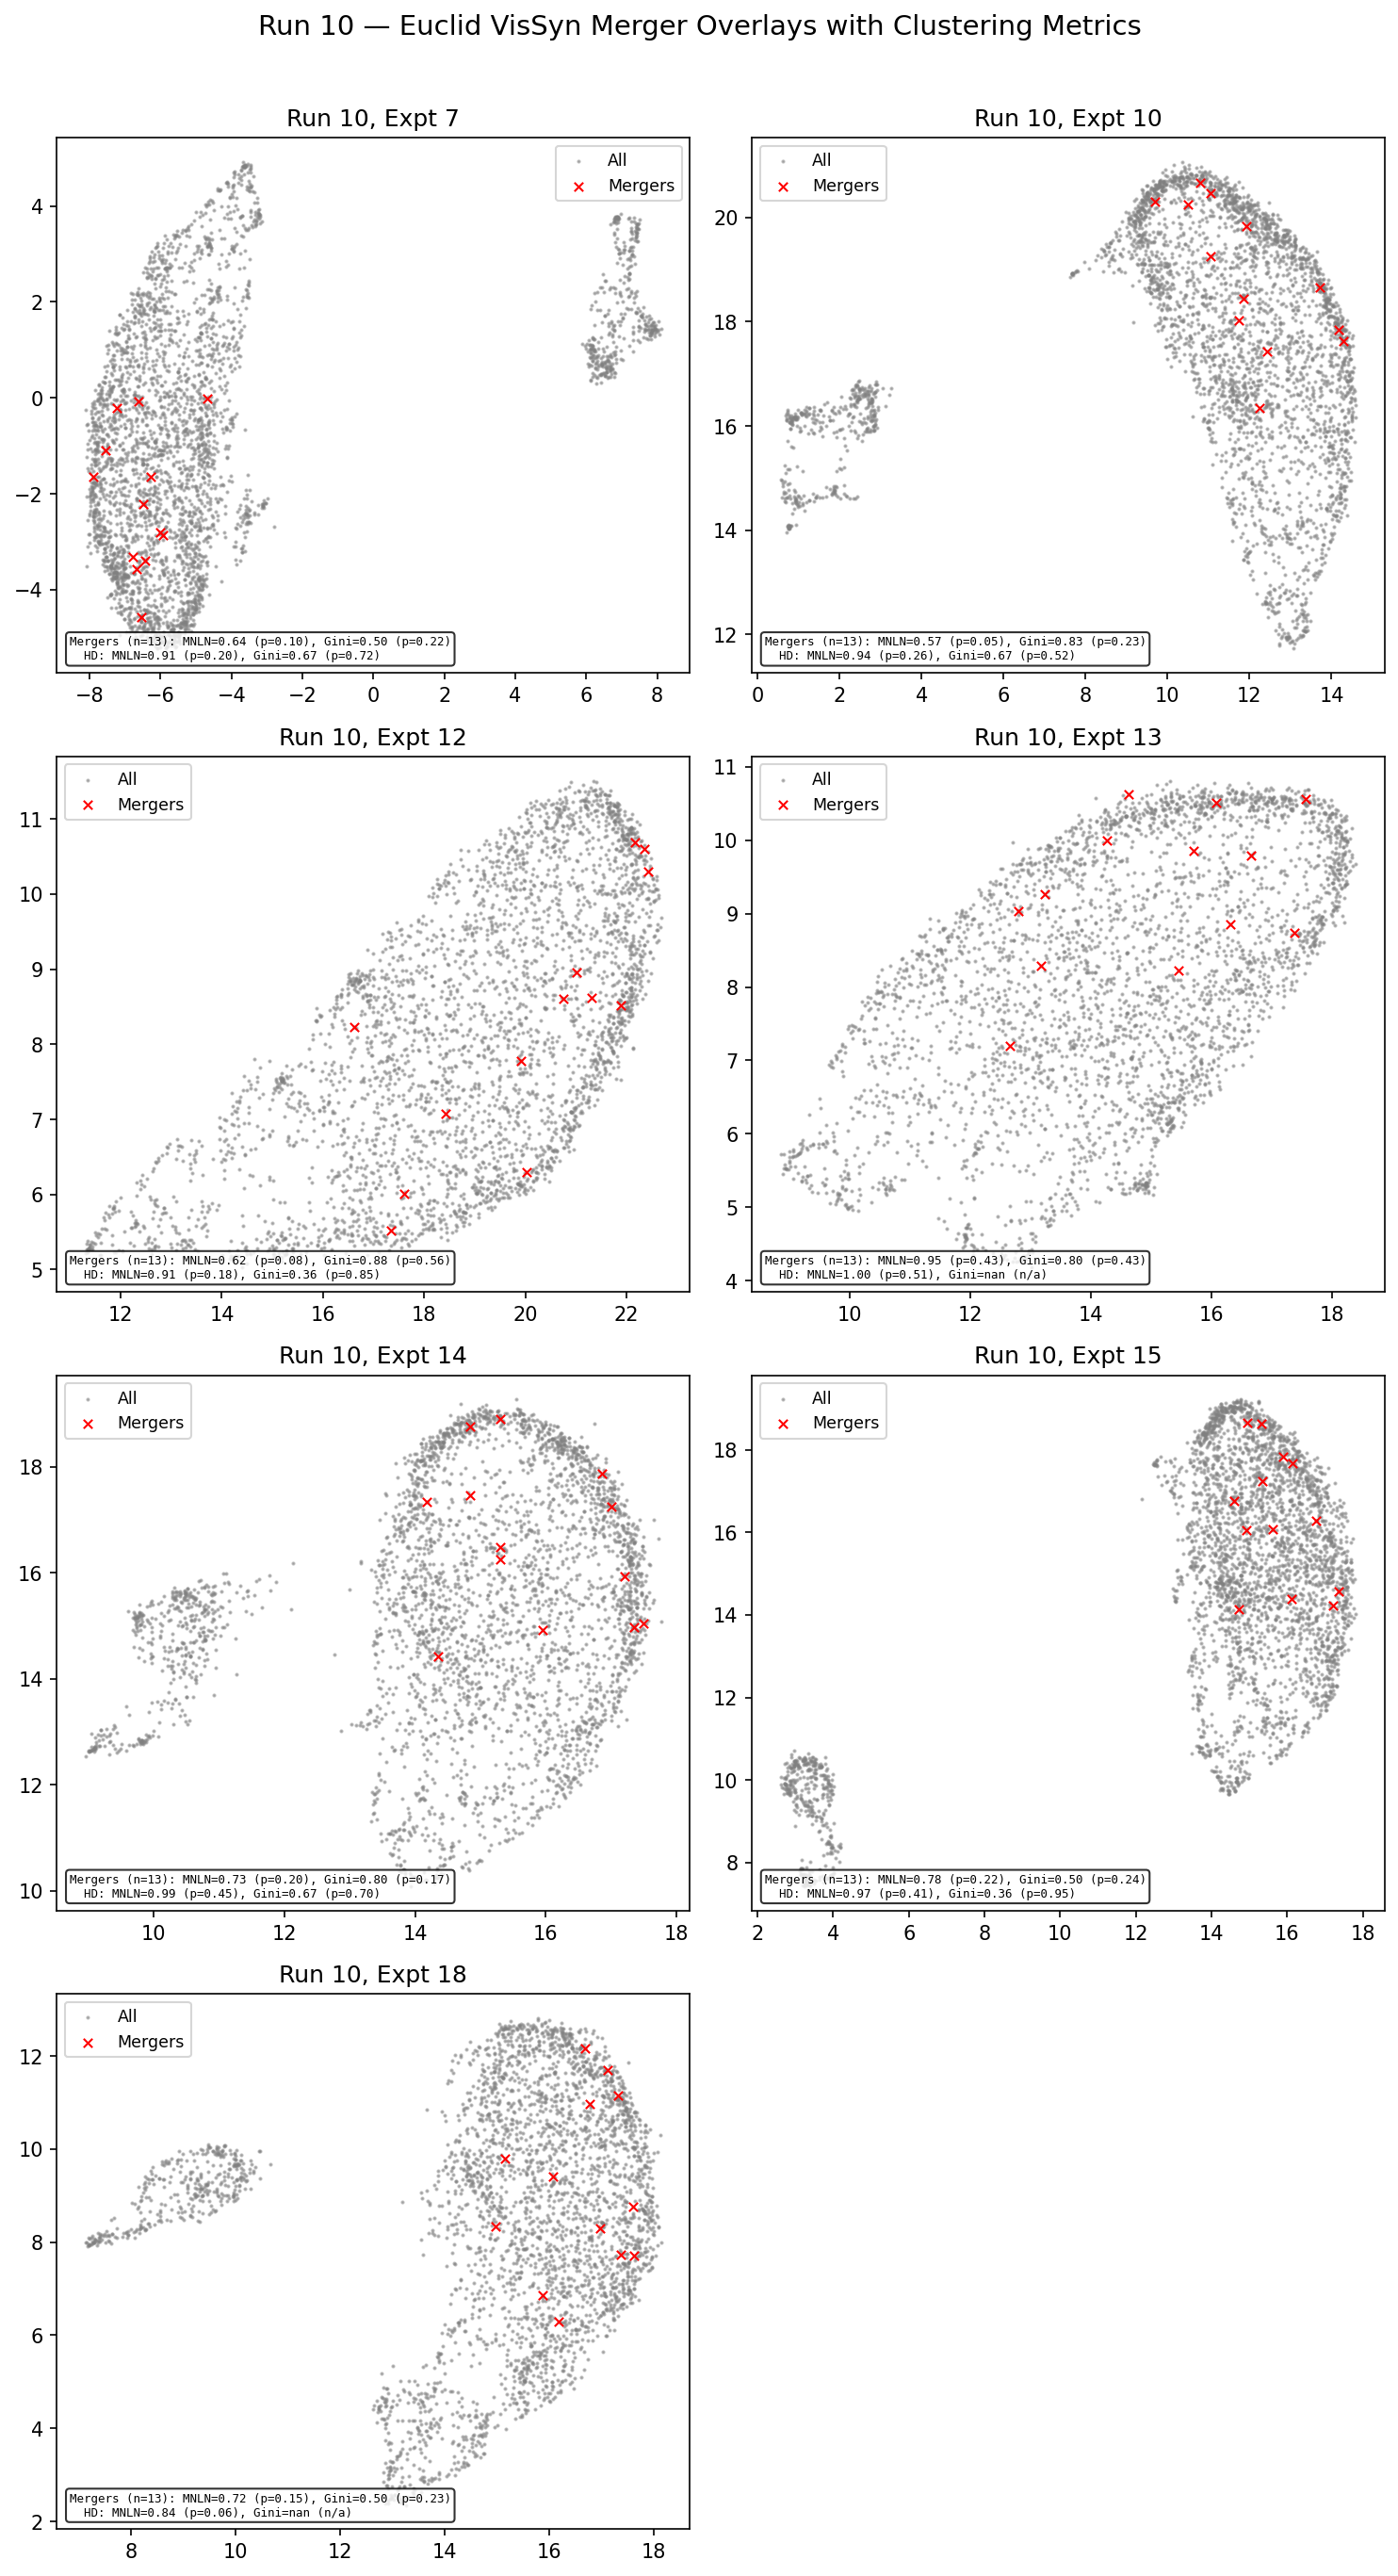

In [30]:
overlays = [
    {'key': 'merging_merger_fraction', 'threshold': 0.7, 'color': 'red', 'marker': 'x', 'label': 'Mergers'},
    #{'key': 'merging_major-disturbance_fraction', 'threshold': 0.55, 'color': 'green', 'marker': 's', 'label': 'Major Merger'},
    #{'key': 'merging_minor-disturbance_fraction', 'threshold': 0.55, 'color': 'blue', 'marker': 's', 'label': 'Minor Merger'},
]

expts = [7, 10, 12, 13, 14, 15, 18]
runs = [10] * len(expts)

fig, all_metrics = plot_multiple_umaps_with_metrics(
    runs, expts, catalog, overlays,
    n_permutations=500,
    include_highdim=True,
    ncols=2,
    alpha_background=0.5,
    show_legend=True,
    suptitle="Run 10 — Euclid VisSyn Merger Overlays with Clustering Metrics",
)

In [31]:
print_metrics_summary(all_metrics, include_hd=True)

 Run  Expt  Overlay                      n    MNLN  p_mnln  Gini  p_gini nClus  MNLN_HD    p_HD Gini_HD   p_gHD
--------------------------------------------------------------------------------------------------------------
  10     7  Mergers                     13   0.641  0.1018 0.500  0.2176     2    0.910  0.2036   0.673  0.7226
  10    10  Mergers                     13   0.569  0.0519 0.833  0.2255     5    0.936  0.2555   0.667  0.5170
  10    12  Mergers                     13   0.620  0.0818 0.885  0.5569    29    0.909  0.1836   0.359  0.8523
  10    13  Mergers                     13   0.946  0.4251 0.800  0.4251     4    1.002  0.5110     n/a     n/a
  10    14  Mergers                     13   0.733  0.1976 0.800  0.1717     4    0.987  0.4511   0.667  0.6986
  10    15  Mergers                     13   0.782  0.2176 0.500  0.2415     2    0.968  0.4052   0.359  0.9521
  10    18  Mergers                     13   0.720  0.1537 0.500  0.2275     2    0.840  0.0619     n/a  

### Run 11

Panels:   0%|          | 0/5 [00:00<?, ?it/s]

/tmp/ipykernel_73175/262614753.py:49: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x[matched_indices], y[matched_indices],
/tmp/ipykernel_73175/262614753.py:49: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x[matched_indices], y[matched_indices],
/tmp/ipykernel_73175/262614753.py:49: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x[matched_indices], y[matched_indices],
/tmp/ipykernel_73175/262614753.py:49: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the

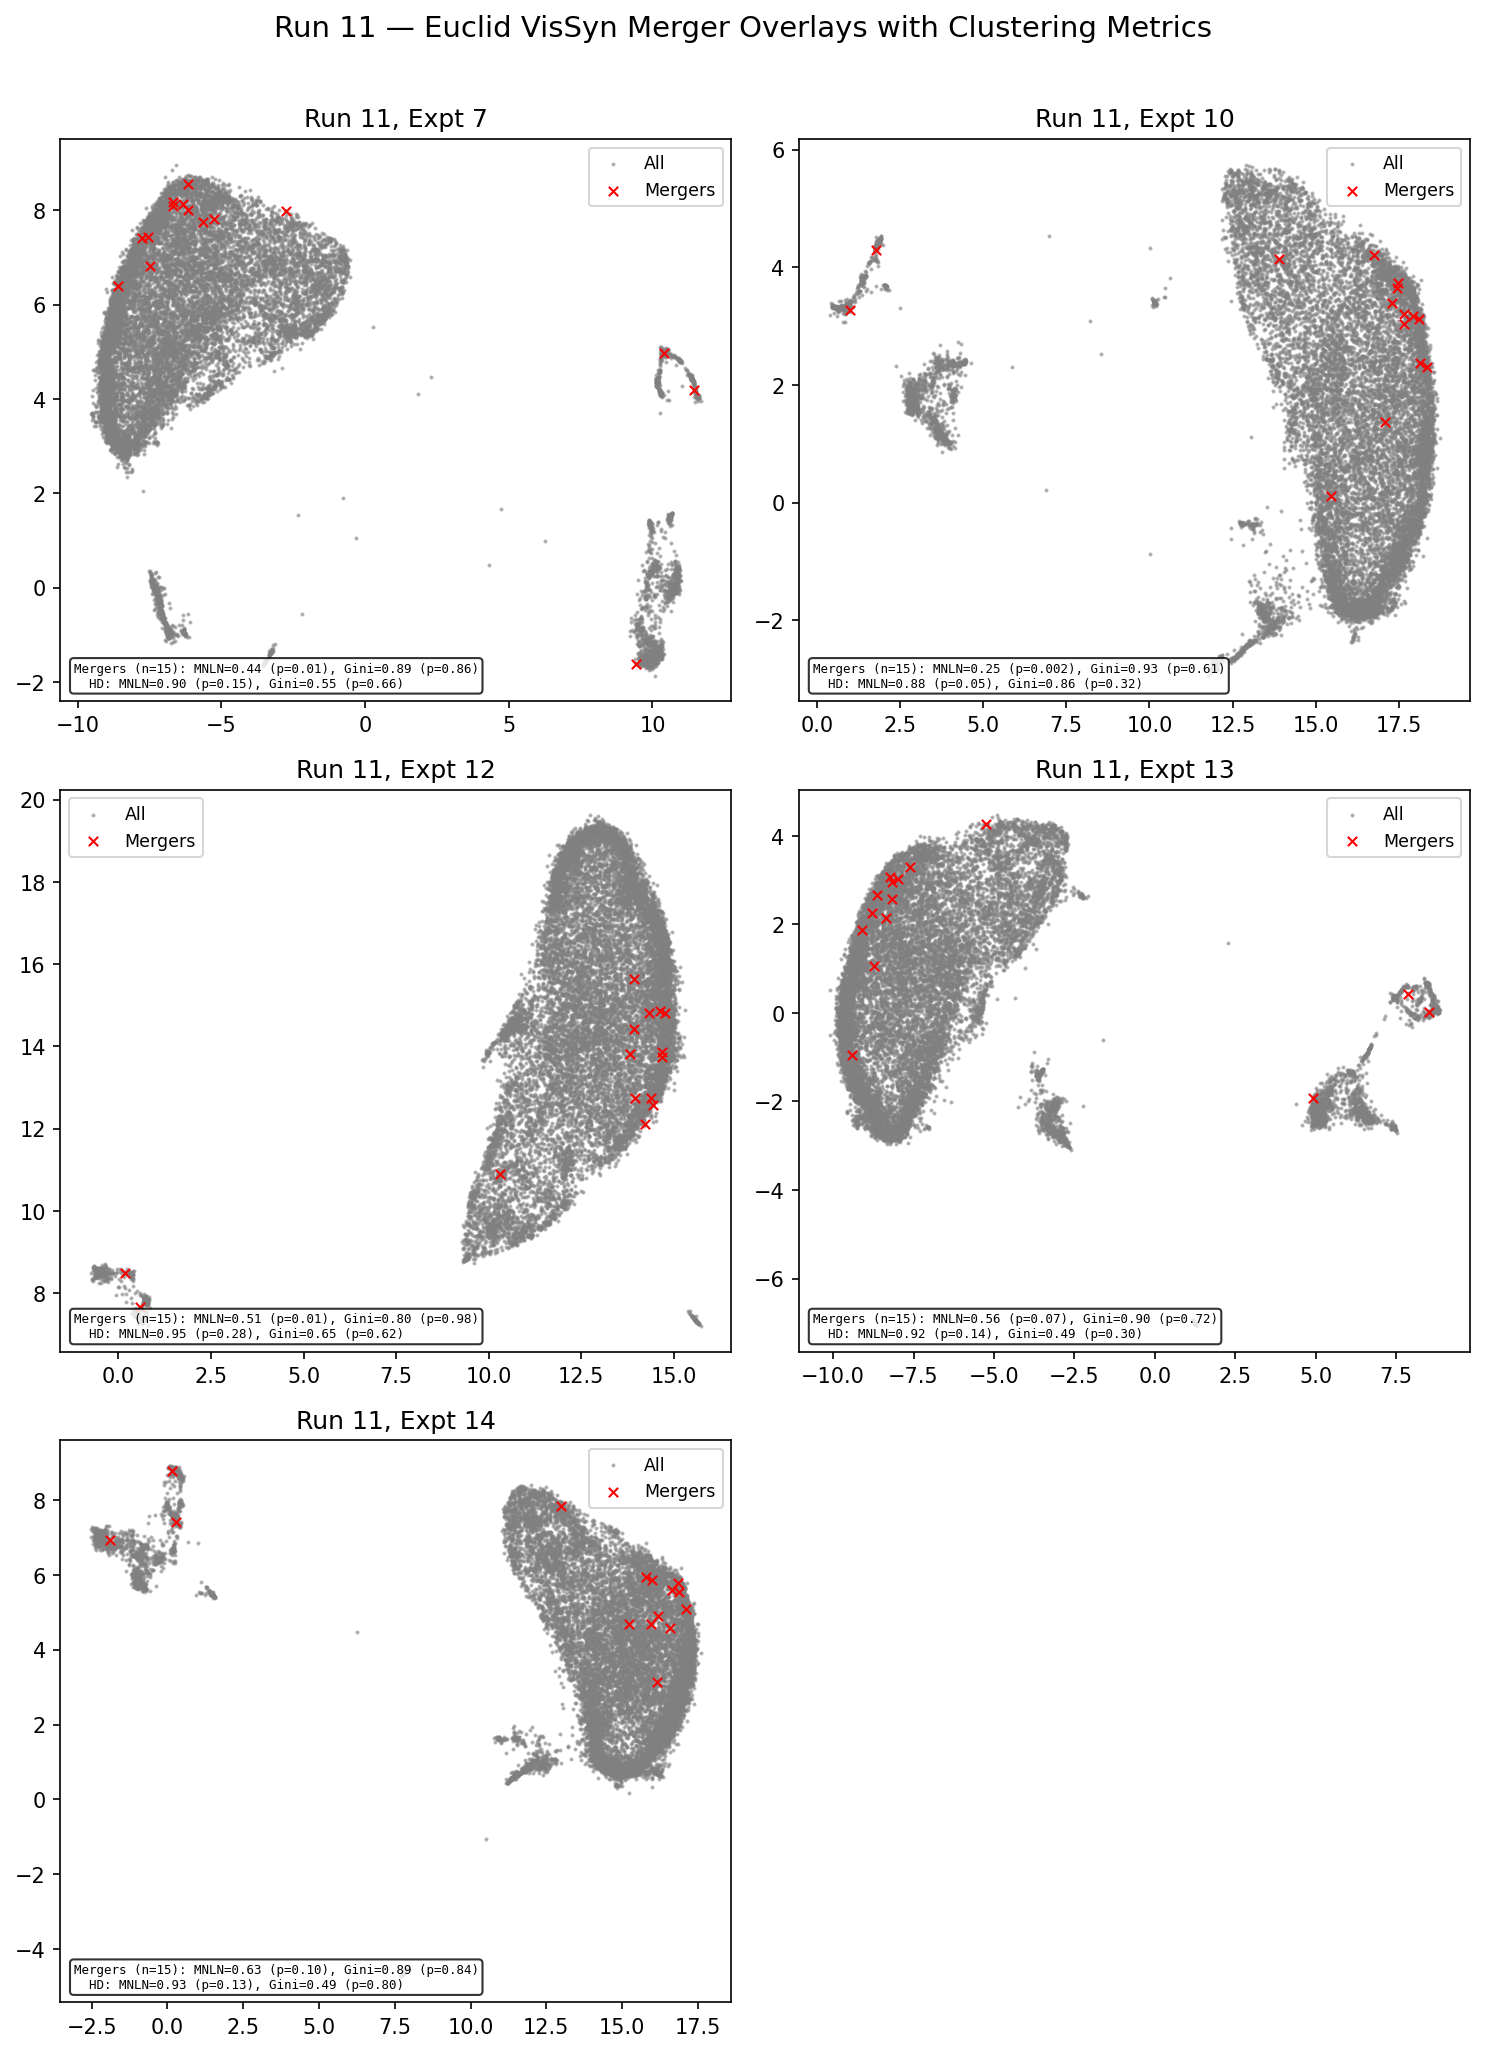

In [34]:
expts = [7, 10, 12, 13, 14]
runs = [11] * len(expts)

fig, all_metrics_r11 = plot_multiple_umaps_with_metrics(
    runs, expts, catalog, overlays,
    n_permutations=500,
    include_highdim=True,
    ncols=2,
    alpha_background=0.5,
    show_legend=True,
    suptitle="Run 11 — Euclid VisSyn Merger Overlays with Clustering Metrics",
)

In [35]:
print_metrics_summary(all_metrics_r11, include_hd=True)

 Run  Expt  Overlay                      n    MNLN  p_mnln  Gini  p_gini nClus  MNLN_HD    p_HD Gini_HD   p_gHD
--------------------------------------------------------------------------------------------------------------
  11     7  Mergers                     15   0.443  0.0140 0.887  0.8563    15    0.904  0.1517   0.550  0.6607
  11    10  Mergers                     15   0.251  0.0020 0.926  0.6108    18    0.881  0.0499   0.857  0.3214
  11    12  Mergers                     15   0.507  0.0120 0.800  0.9760     6    0.950  0.2814   0.650  0.6228
  11    13  Mergers                     15   0.564  0.0659 0.898  0.7186    14    0.921  0.1417   0.489  0.3014
  11    14  Mergers                     15   0.633  0.0998 0.887  0.8363    15    0.925  0.1297   0.489  0.8044


## Euclid Lens Candidates

In [ ]:
lens_overlays = [
    {'key': None, 'color': 'red', 'marker': 'o', 'label': 'Euclid Lens Candidates'},
]

expts = [7, 10, 12, 13, 14, 15, 18]
runs = [10] * len(expts)

fig, lens_metrics = plot_multiple_umaps_with_metrics(
    runs, expts, euclid_lens_catalog, lens_overlays,
    n_permutations=500,
    include_highdim=True,
    ncols=2,
    alpha_background=0.5,
    show_legend=True,
    suptitle="Run 10 — Euclid Lens Candidates with Clustering Metrics",
)

In [ ]:
print_metrics_summary(lens_metrics, include_hd=True)

## DES Low Surface Brightness Candidates

In [ ]:
lsb_overlays = [
    {'key': None, 'color': 'red', 'marker': 'o', 'label': 'DES LSB Candidates'},
]

expts = [7, 10, 12, 13, 14, 15, 18]
runs = [10] * len(expts)

fig, lsb_metrics = plot_multiple_umaps_with_metrics(
    runs, expts, des_lsb_catalog, lsb_overlays,
    n_permutations=500,
    include_highdim=True,
    ncols=2,
    alpha_background=0.5,
    show_legend=True,
    suptitle="Run 10 — DES LSB Candidates with Clustering Metrics",
)

In [ ]:
print_metrics_summary(lsb_metrics, include_hd=True)

## Single-Run Deep DiveFor a single run/experiment, inspect the full metric output.

In [ ]:
run, expt = 10, 12
umap_dir, inference_dir, config_file = extract_umap_info(run, expt)
h = hyrax.Hyrax(config_file=config_file)
umap_data = get_umap_with_ids(config=h.config, input_dir=umap_dir)
hd = get_highdim_data(h.config, inference_dir) if inference_dir else None

overlays_all = [
    {'key': 'merging_merger_fraction', 'threshold': 0.7, 'color': 'red', 'marker': 'x', 'label': 'Mergers (Euclid)'},
    {'key': 'merging_major-disturbance_fraction', 'threshold': 0.55, 'color': 'green', 'marker': 's', 'label': 'Major Merger (Euclid)'},
]

metrics = compute_overlay_metrics(umap_data, catalog, overlays_all, highdim_coords=hd)

for m in metrics:
    print(f"\n=== {m['label']} (n={m['n_matched']}) ===")
    mnln = m['mnln_2d']
    cmc = m['cmc_2d']
    print(f"  2D UMAP:")
    print(f"    MNLN ratio:  {mnln['ratio']:.3f}  (observed={mnln['observed']:.3f}, expected={mnln['expected']:.3f}, z={mnln['z_score']:.2f}, p={mnln['p_value']:.4f})")
    print(f"    CMC Gini:    {cmc['gini']:.3f}  (expected={cmc['expected_gini']:.3f}, z={cmc['z_score']:.2f}, p={cmc['p_value']:.4f}, clusters={cmc['n_clusters']})")
    if cmc['cluster_counts']:
        print(f"    Cluster distribution: {cmc['cluster_counts']}")
    if 'mnln_hd' in m:
        mnln_hd = m['mnln_hd']
        cmc_hd = m['cmc_hd']
        print(f"  High-Dim Latent:")
        print(f"    MNLN ratio:  {mnln_hd['ratio']:.3f}  (observed={mnln_hd['observed']:.3f}, expected={mnln_hd['expected']:.3f}, z={mnln_hd['z_score']:.2f}, p={mnln_hd['p_value']:.4f})")
        print(f"    CMC Gini:    {cmc_hd['gini']:.3f}  (expected={cmc_hd['expected_gini']:.3f}, z={cmc_hd['z_score']:.2f}, p={cmc_hd['p_value']:.4f}, clusters={cmc_hd['n_clusters']})")
        if cmc_hd['cluster_counts']:
            print(f"    Cluster distribution: {cmc_hd['cluster_counts']}")